In [2]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv('Churn_Modelling.csv')
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [8]:
df.head(20)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [10]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [14]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool

In [16]:
df.drop(columns = ['RowNumber','CustomerId','Surname'],inplace = True)

In [18]:
df.head(10)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [20]:
df = pd.get_dummies(df,columns = ['Geography','Gender'],drop_first = True)


In [22]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,0,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,1,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,1,True,False,True


In [24]:
X = df.drop(columns = 'Exited')
y = df['Exited']

In [26]:
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,True,False,True


In [28]:
y

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int64

In [30]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state = 42)


In [32]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [34]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense


In [38]:
X_train_scaled.shape

(8000, 11)

In [66]:
model = Sequential()

model.add(Dense(11,activation = 'relu',input_dim = 11))
model.add(Dense(11,activation = 'relu'))
model.add(Dense(1,activation = 'sigmoid'))
          


/opt/anaconda3/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [68]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [72]:
model.compile(loss = 'binary_crossentropy',optimizer = 'Adam',metrics = ['accuracy'])

In [88]:
history = model.fit(X_train_scaled,y_train,epochs = 250,validation_split = 0.2)

Epoch 1/250
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 348us/step - accuracy: 0.8667 - loss: 0.3129 - val_accuracy: 0.8550 - val_loss: 0.3443
Epoch 2/250
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 262us/step - accuracy: 0.8758 - loss: 0.2957 - val_accuracy: 0.8606 - val_loss: 0.3424
Epoch 3/250
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 257us/step - accuracy: 0.8747 - loss: 0.3023 - val_accuracy: 0.8600 - val_loss: 0.3425
Epoch 4/250
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 260us/step - accuracy: 0.8696 - loss: 0.3071 - val_accuracy: 0.8587 - val_loss: 0.3415
Epoch 5/250
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 259us/step - accuracy: 0.8655 - loss: 0.3095 - val_accuracy: 0.8569 - val_loss: 0.3443
Epoch 6/250
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 258us/step - accuracy: 0.8776 - loss: 0.3030 - val_accuracy: 0.8581 - val_loss: 0.3438
Epoch 7/250
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 256us/step - accuracy: 0.8701 - loss: 0.3097 - val_accuracy: 0.8606 - val_loss: 0.3451
Epoch 8/250
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 259us/step - accuracy: 0.8763 - loss: 0

In [78]:
model.layers[0].get_weights()

[array([[-2.12116420e-01,  9.78164189e-03, -1.29799053e-01,
          3.53842489e-02, -1.05960295e-01, -5.49933434e-01,
         -7.08407834e-02, -3.95241193e-02, -3.01403522e-01,
         -1.45692313e-02, -9.63749513e-02],
        [ 8.13014269e-01,  8.16094160e-01,  8.40039807e-04,
         -1.03717518e+00,  1.66466206e-01,  8.80828872e-03,
          1.27867067e+00, -1.13847159e-01,  1.02922417e-01,
         -5.35959065e-01, -6.41174138e-01],
        [-4.11321759e-01, -1.36303157e-01, -6.22920573e-01,
         -7.74020851e-02, -3.05032492e-01, -8.34275544e-01,
         -1.83315217e-01, -5.69553748e-02, -3.51957858e-01,
         -1.51048750e-01, -3.02291870e-01],
        [ 3.50846261e-01, -1.22589618e-01,  7.22736955e-01,
         -1.08809836e-01, -3.21061701e-01,  4.46016997e-01,
         -6.76735461e-01, -4.58426088e-01,  7.42388546e-01,
         -6.85200810e-01,  4.75159913e-01],
        [ 1.15884101e+00, -9.49962616e-01, -6.90587580e-01,
          3.51501614e-01,  9.80460763e-01, -

In [80]:
y_log = model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 382us/step


In [82]:
y_pred = np.where(y_log > 0.5,1,0)

In [84]:
from sklearn.metrics import accuracy_score
print("Accuracy_score: ",accuracy_score(y_test,y_pred))

Accuracy_score:  0.85


In [86]:
import matplotlib.pyplot as plt

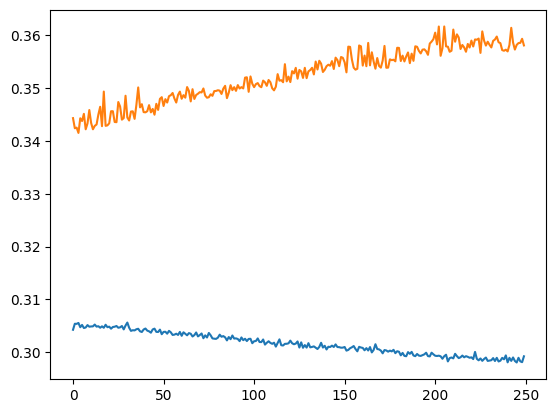

In [90]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

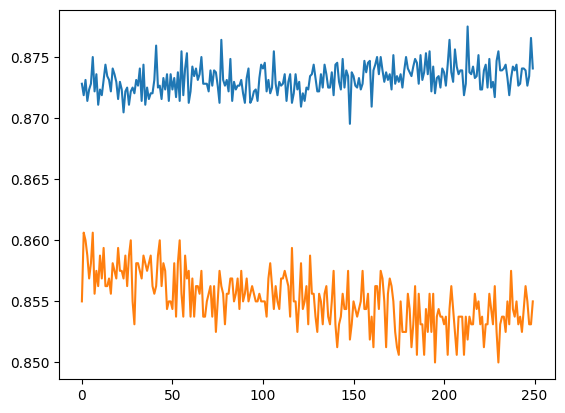

In [92]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

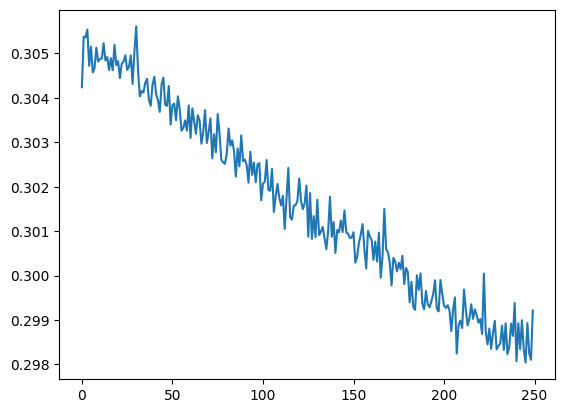

In [94]:
plt.plot(history.history['loss'])

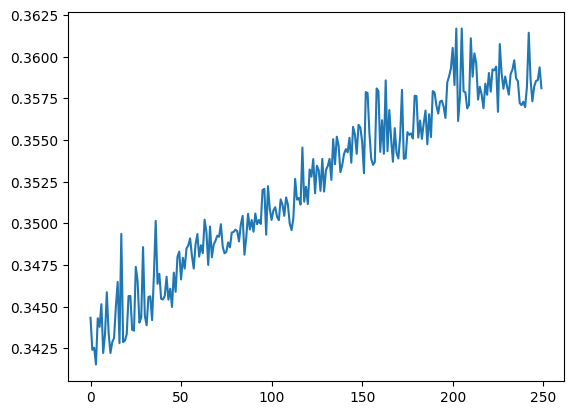

In [96]:
plt.plot(history.history['val_loss'])